In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test  = pd.read_csv("y_test.csv").values.ravel()

## Identifying Numerical and Categorical Features

In [3]:
X_train.dtypes.value_counts()

float64    13
object      2
int64       1
dtype: int64

In [4]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 14
Categorical features: 2


## Preprocessing Pipelines
I prepear the numeric and categorical pipelines for data imputatation, scaling and creating dummies for the categories.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [7]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [8]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Logistic Regression Model & Full Pipeline

In [9]:
from sklearn.linear_model import LogisticRegressionCV

log_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l2",
    scoring="roc_auc",
    max_iter=1000,
    n_jobs=-1,
    refit=True
)

In [10]:
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", log_model)
])

## Fit and Preformance Evaluation

In [11]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'log_annual_inc'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['purpose', 'home_ownership'], dtype='object'))])),
                ('model',
                 LogisticRegressionCV(cv=5, max_iter=1000, n_jobs=-1,
                                      scoring='roc_auc'))])

In [12]:
from sklearn.metrics import roc_auc_score, classification_report

# Predict probabilities
train_probs = clf.predict_proba(X_train)[:, 1]
test_probs  = clf.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
test_auc  = roc_auc_score(y_test, test_probs)

print("Train AUC:", round(train_auc, 4))
print("Test AUC :", round(test_auc, 4))

Train AUC: 0.7061
Test AUC : 0.6965


In [16]:
import json
from datetime import datetime

logistic_metrics = {
    "model": "Logistic Regression",
    "train_auc": round(train_auc, 4),
    "test_auc": round(test_auc, 4),
    "validation_split": "Train: ≤2016 | Test: ≥2017",
    "timestamp": datetime.now().isoformat()
}

with open("../public/logistic_metrics.json", "w") as f:
    json.dump(logistic_metrics, f, indent=4)

print("Saved logistic_metrics.json")

Saved logistic_metrics.json


## Sanity Cell
I check for the specific coeficients in order to verify economic consistency.

In [13]:
import numpy as np

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Get feature names after preprocessing
ohe = clf.named_steps["preprocessor"] \
         .named_transformers_["cat"] \
         .named_steps["encoder"]

cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_feature_names])

# Extract coefficients
coefficients = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

display(coef_df)


,feature,coefficient
2,int_rate,0.410715
25,purpose_small_business,0.333244
1,term,0.305055
3,installment,0.202882
5,dti,0.154844
24,purpose_renewable_energy,0.149853
8,open_acc,0.147847
17,purpose_educational,0.140471
21,purpose_medical,0.129470
28,home_ownership_ANY,0.127141


In [14]:
clf.named_steps["model"].C_

array([21.5443469])

## Calibration Curve

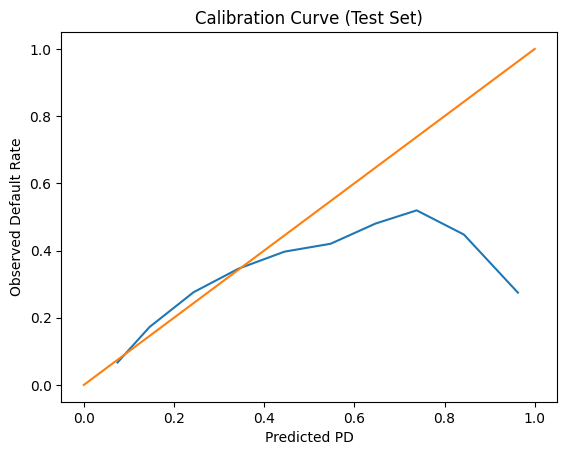

In [17]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true)
plt.plot([0, 1], [0, 1])
plt.xlabel("Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve (Test Set)")
plt.savefig("../public/calibration_curve_logistic.png", dpi=300, bbox_inches="tight")
plt.show()